In [1]:
import os
import sys

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '..'))

from data_processing import DataProcessing

In [2]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
results_dir = os.path.join(base_data_path, "classification_results/combined-full_synthetic-v1_2026-03-07/seed42")

In [3]:
dfs = []
files = os.listdir(results_dir)
for file in files:
    # print(file)
    if "learning_metrics" in file:
        print(file)
        file_to_load = os.path.join(results_dir, file)
        df = DataProcessing.load_from_file(file_to_load)
        dfs.append(df)

learning_metrics_df = DataProcessing.concat_dfs(dfs)
learning_metrics_df

learning_metrics_ridge_classifier.csv
learning_metrics_random_forest_classifier.csv
learning_metrics_gradient_boosting_classifier.csv
learning_metrics_perceptron.csv
learning_metrics_logistic_regression.csv
learning_metrics_sgd_classifier.csv
learning_metrics_support_vector_machine_classifier.csv
learning_metrics_decision_tree_classifier.csv
learning_metrics_x_gradient_boosting_classifier.csv


,model,train_accuracy,val_accuracy
0,ridge_classifier,0.997623,1.000000
1,random_forest_classifier,1.000000,0.976247
2,gradient_boosting_classifier,1.000000,0.971496
3,perceptron,1.000000,0.997625
4,logistic_regression,0.996038,1.000000
5,sgd_classifier,0.999208,0.995249
6,support_vector_machine_classifier,0.997623,0.995249
7,decision_tree_classifier,1.000000,0.798100
8,x_gradient_boosting_classifier,1.000000,0.971496


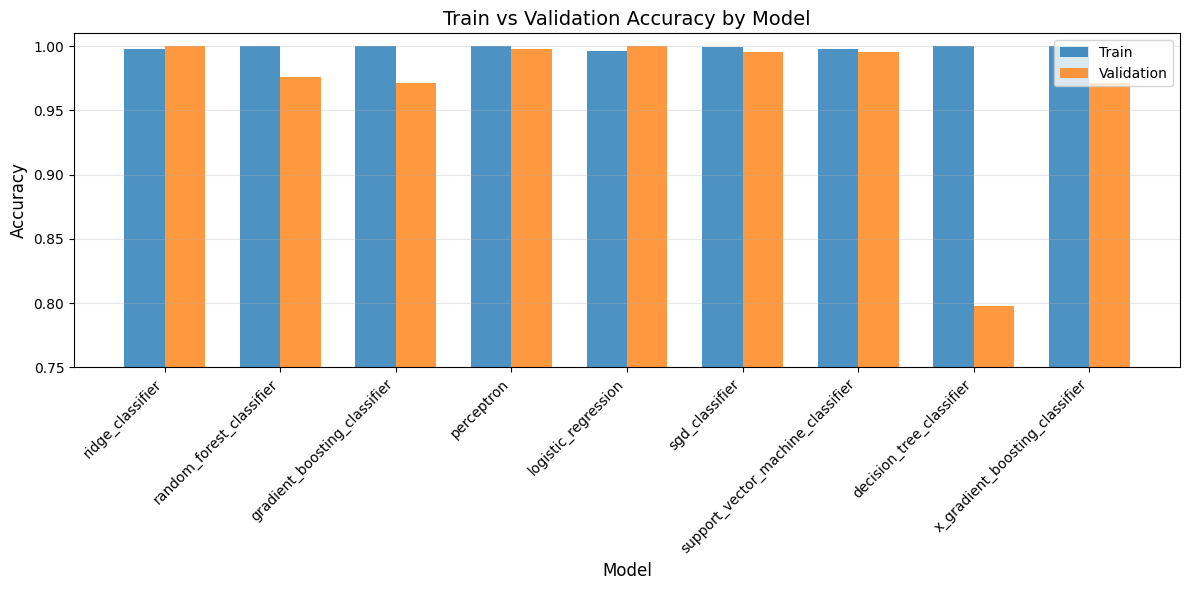

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your CSV
# df = pd.read_csv('learning_metrics_combined.csv')  # or wherever it's saved

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Set up x positions
x = np.arange(len(learning_metrics_df))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, learning_metrics_df['train_accuracy'], width, label='Train', alpha=0.8)
bars2 = ax.bar(x + width/2, learning_metrics_df['val_accuracy'], width, label='Validation', alpha=0.8)

# Customize
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Validation Accuracy by Model', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(learning_metrics_df['model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0.75, 1.01])  # Focus on relevant range
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('train_val_comparison.png', dpi=300)
plt.show()

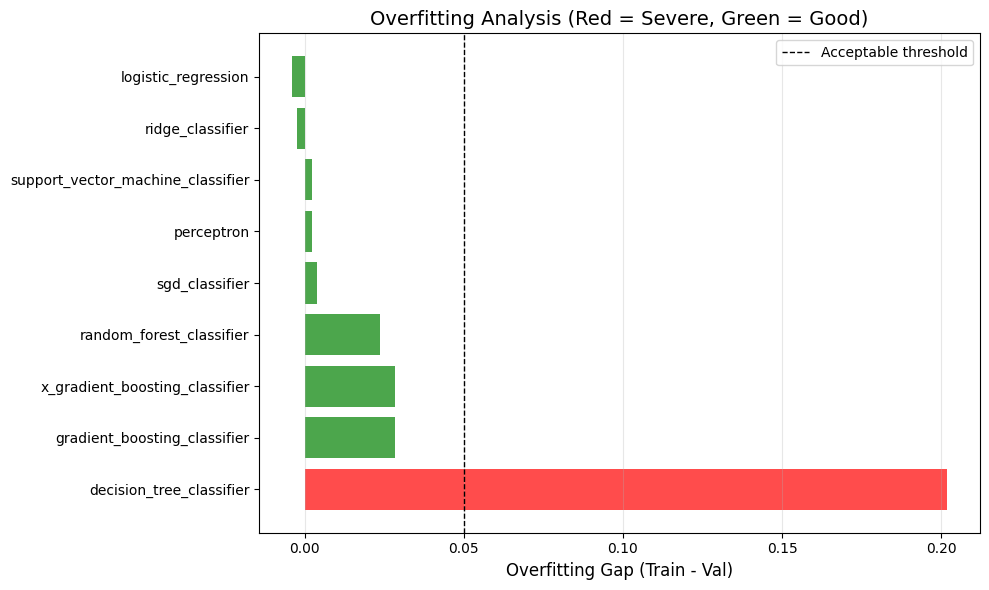

In [7]:
# Calculate overfitting gap
learning_metrics_df['gap'] = learning_metrics_df['train_accuracy'] - learning_metrics_df['val_accuracy']

# Sort by gap (worst overfitters first)
df_sorted = learning_metrics_df.sort_values('gap', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if gap > 0.1 else 'orange' if gap > 0.05 else 'green' 
          for gap in df_sorted['gap']]

ax.barh(df_sorted['model'], df_sorted['gap'], color=colors, alpha=0.7)
ax.set_xlabel('Overfitting Gap (Train - Val)', fontsize=12)
ax.set_title('Overfitting Analysis (Red = Severe, Green = Good)', fontsize=14)
ax.axvline(x=0.05, color='black', linestyle='--', linewidth=1, label='Acceptable threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
# plt.savefig('overfitting_gap.png', dpi=300)
plt.show()